# Fine-tuning with Unsloth

Here, I go through one example of finetuning using unsloth. I finetuned Phi4 twice: once with 3k examples so that it trained more quickly and one with 20k examples to take full advantage of the size of the dataset. The process described below was the exact same for each, with the one exception being the size of the training and validation datasets.

## Setup
Setup included imports, loading the previous dataset, and making sure that it was properly balanced for training.

### Imports

In [1]:
import json
import torch
import warnings
from pathlib import Path
from datasets import load_from_disk, concatenate_datasets
from unsloth import FastLanguageModel, is_bfloat16_supported
from unsloth.chat_templates import train_on_responses_only
from trl import SFTTrainer
from transformers import TrainingArguments, TrainerCallback, EarlyStoppingCallback

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


### Check GPU Usage before beginning training

In [2]:
## Checking GPU Usage before training
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA A40. Max memory = 44.422 GB.
0.021 GB of memory reserved.


### Loading previous dataset

In [7]:
## Load dataset 
dataset = load_from_disk("../data/ai4privacy/pii-masking-300k_processed")

In [8]:
print(dataset)

Dataset({
    features: ['source_text', 'contains_pii', 'pii_tags', 'ai4privacy_text', 'tagged_text', 'NAME', 'TITLE', 'DOB', 'DATE', 'TIME', 'EMAIL', 'PHONE', 'ADDRESS', 'LOCATION', 'SSN', 'UNIQUE_ID', 'LICENSE_NUMBER', 'IP_ADDRESS', 'USERNAME', 'PASS', 'SEX', 'CARDISSUER'],
    num_rows: 29713
})


## Data Selection

### Create the dataset I want to use for fine tuning
I want to make sure to use a balanced dataset when fine tuning to make sure that the model doesn't hallucinate pii in every scenario. Here, I am going to aim for 10-15% without pii at all.

For my inital testing, I created a train size of 100, just to make sure my pipeline was worked. For my first solution, I used a training size of 3000 and a evaluation size of 750 to balance with providing enough data, while still making it moderately fast to train. Finally, I tried using all of the dataset, with 10% separated for evaluation.

In [9]:
def create_balanced_dataset(mixed_dataset, train_size=3000, eval_size=750):
    includes_pii_dataset = mixed_dataset.filter(lambda x: x["contains_pii"] == True)
    no_pii_dataset = mixed_dataset.filter(lambda x: x["contains_pii"] == False)

    ## Train
    num_no_pii = int(train_size * 0.15)
    num_pii = train_size - num_no_pii

    ## Eval
    num_eval_no_pii   = int(eval_size * 0.15)    # 112
    num_eval_pii    = eval_size - num_eval_no_pii

    pii_sample = includes_pii_dataset.shuffle(seed=42).select(range(num_pii))
    eval_pii = includes_pii_dataset.shuffle(seed=42).select(range(num_pii, num_pii + num_eval_pii))

    no_pii_sample = no_pii_dataset.shuffle(seed=42).select(range(num_no_pii))
    eval_no_pii = no_pii_dataset.shuffle(seed=42).select(range(num_no_pii, num_no_pii + num_eval_no_pii))


    train_dataset = concatenate_datasets([pii_sample, no_pii_sample]).shuffle(seed=42)
    eval_dataset = concatenate_datasets([eval_pii, eval_no_pii]).shuffle(seed=42)
    return train_dataset, eval_dataset

In [14]:
dataset_size = dataset.num_rows
print(dataset.num_rows)

29713


In [18]:
train_size = 20000
eval_size = 2000
training_dataset, eval_dataset = create_balanced_dataset(dataset, train_size=train_size, eval_size=eval_size)
print(training_dataset)

Dataset({
    features: ['source_text', 'contains_pii', 'pii_tags', 'ai4privacy_text', 'tagged_text', 'NAME', 'TITLE', 'DOB', 'DATE', 'TIME', 'EMAIL', 'PHONE', 'ADDRESS', 'LOCATION', 'SSN', 'UNIQUE_ID', 'LICENSE_NUMBER', 'IP_ADDRESS', 'USERNAME', 'PASS', 'SEX', 'CARDISSUER'],
    num_rows: 20000
})


In [19]:
## Double checking the distribution:
free_count = sum(1 for x in training_dataset if not x["contains_pii"])
print(f"PII-free: {free_count} ({free_count/len(training_dataset):.1%})")

PII-free: 3000 (15.0%)


### Formating the data to be in a prompt format

This step is essential since Phi4 is trained to follow instructions.

In [21]:
SYSTEM_PROMPT = """
You are a personally identifiable information (PII) redaction assistant. Wrap all personally identifiable
information in XML-style tags sych as <NAME>, <DOB>, <PHONE, <ADDRESS>, <LOCATION> etc. 
Rules:
- Return the FULL transcript with PII tagged.
- Do NOT change any non-PII text.
- If no PII is present, return the transcript unchanged.
"""

In [22]:
def format_example(row):
    return {
        "messages": [
            {"role": "system",  "content": SYSTEM_PROMPT},
            {"role": "user",    "content": f"Redact the following text:\n\n{row['source_text']}"},
            {"role": "assistant","content": row["tagged_text"]},
        ]
    }

In [23]:
formatted_train = training_dataset.map(format_example)
formatted_eval = eval_dataset.map(format_example)

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [25]:
# Santiy Check
print(formatted_train)

Dataset({
    features: ['source_text', 'contains_pii', 'pii_tags', 'ai4privacy_text', 'tagged_text', 'NAME', 'TITLE', 'DOB', 'DATE', 'TIME', 'EMAIL', 'PHONE', 'ADDRESS', 'LOCATION', 'SSN', 'UNIQUE_ID', 'LICENSE_NUMBER', 'IP_ADDRESS', 'USERNAME', 'PASS', 'SEX', 'CARDISSUER', 'messages'],
    num_rows: 20000
})


In [27]:
train_size = formatted_train.num_rows
with open(f"../data/train_{train_size}.jsonl", "w") as f:
    for example in formatted_train:
        f.write(json.dumps({"messages": example["messages"]}) + "\n")

In [29]:
## Print an example
print(formatted_train[0]['messages'])

[{'role': 'system', 'content': '\nYou are a personally identifiable information (PII) redaction assistant. Wrap all personally identifiable\ninformation in XML-style tags sych as <NAME>, <DOB>, <PHONE, <ADDRESS>, <LOCATION> etc. \nRules:\n- Return the FULL transcript with PII tagged.\n- Do NOT change any non-PII text.\n- If no PII is present, return the transcript unchanged.\n'}, {'role': 'user', 'content': 'Redact the following text:\n\n, London\n\n**Patient Information:**\n\n1. **Patient:**\n   - Name: Stavri Lipperini\n   - Sex: M\n   - Username: stavrkayar\n   - Social Security Number: 476683185\n   - Contact Number: 075.753-8390\n\n2. **Patient:**\n   - Name: Scotty Druga\n   - Sex: Male\n   - Username: 25scotty.gruchalski\n   - Social Security Number: 1536682382\n   - Contact Number: 019-460.200 2771\n\n...and so forth for'}, {'role': 'assistant', 'content': ', London\n\n**Patient Information:**\n\n1. **Patient:**\n   - Name: <NAME>Stavri</NAME> <NAME>Lipperini</NAME>\n   - Sex: 

## Prepare Logging

One thing I learned throughout the semester is that having quality logs are essential when working with log-running processes (such as training) so that you may resume if interupted. 

In [30]:
## Use this for loggin
class LossHistoryCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.eval_losses  = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        if "loss" in logs:
            self.train_losses.append({
                "step": state.global_step,
                "loss": logs["loss"]
            })
        if "eval_loss" in logs:
            self.eval_losses.append({
                "step": state.global_step,
                "loss": logs["eval_loss"]
            })

## Formating to a Chat template

Once again, Phi4 must take in a very specific format since it is finetuned to take instructions.

In [31]:
def formatting_func(examples):
    convos = examples["messages"]
    texts = [
        tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False)
        for convo in convos
    ]
    return texts

## Load the model

Key decisions:
- dropout:  zero here to take advantage of the Unsloth fast patching. I initially tried 0.05, but that was much slower due to not benefiting from Unsloth's speed-ups.
- load_in_4_bit: allows for less VRAM usage
- max_seq_length: prevents memory spikes from unexpectedly long inputs
- lora rank: 16 to balance memory needs with expressiveness
- target_modules: explains which attention layers and FFN layers to target with the finetuning. I used recommendations from tutorials.
- gradient checkpointing: uses Unsloth's optimized version to reduce memory usage

In [33]:
loss_history = LossHistoryCallback()
    
# Load model with 4-bit quantization
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/phi-4",
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True, # Note for self, load in 4 bit for colab
)

# Attach LoRA adapter
model = FastLanguageModel.get_peft_model(
    model,
    r=16,                  # LoRA rank
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"], ## Note to self, research if all of these layers are necessary 
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",  # reduces memory usage during back propogation 
    random_state=42,
)

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L40S. Num GPUs = 1. Max memory: 44.392 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/363 [00:00<?, ?it/s]

Unsloth 2026.4.8 patched 40 layers with 40 QKV layers, 40 O layers and 40 MLP layers.


## Create the SFT Trainer
Note, you can add
```
save_total_limit=3, 
```
in the `TrainingArguments` below if you are worried about disk space. This will limit the number of checkpoints saved. 

In [6]:
## where checkpoint will save
CHECKPOINT_DIR = "../checkpoints_20000"

In [40]:
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=formatted_train,
    eval_dataset=formatted_eval,
    formatting_func=formatting_func,
    max_seq_length=2048,
    callbacks=[loss_history],
    args=TrainingArguments(
        output_dir=CHECKPOINT_DIR,
        num_train_epochs=10,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        warmup_steps=5,
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),

        # Saving 
        save_strategy="epoch",  # save every epoch
        eval_strategy="epoch",
        load_best_model_at_end=True, 
        metric_for_best_model="eval_loss",
        greater_is_better=False,

        # Updating the Weights
        optim="adamw_8bit",
        weight_decay=0.01,

        # Logging
        logging_steps=10,
        report_to="none",
    ),
)

trainer = train_on_responses_only(
    trainer,
    instruction_part="<|im_start|>user<|im_sep|>",
    response_part="<|im_start|>assistant<|im_sep|>",
)

[accelerate.utils.other|WARNING][RANK 0] Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Ensure that it is working as expected before running the full training:

In [41]:
sample = trainer.train_dataset[5]

In [42]:
print(tokenizer.decode(sample["input_ids"]))

<|im_start|>system<|im_sep|>You are a personally identifiable information (PII) redaction assistant. Wrap all personally identifiable
information in XML-style tags sych as <NAME>, <DOB>, <PHONE, <ADDRESS>, <LOCATION> etc. 
Rules:
- Return the FULL transcript with PII tagged.
- Do NOT change any non-PII text.
- If no PII is present, return the transcript unchanged.<|im_end|><|im_start|>user<|im_sep|>Redact the following text:

**Email 1 - From Student to School Administration**  
Subject: Inquiry Regarding Class Schedule for Fall Semester  
Dear Admin Team,  
I hope this email finds you well. I am writing to inquire about the class schedule for the upcoming Fall semester. I have reviewed my planned courses and would like to confirm the timings and locations of these classes. Your prompt response would be greatly appreciated.  
Thank you in advance,  
Username: adevija.jariff  

**Ema<|im_end|><|im_start|>assistant<|im_sep|>**Email 1 - From Student to School Administration**  
Subject: I

In [43]:
for token_id, label in zip(sample["input_ids"], sample["labels"]):
    if label != -100:
        print(repr(tokenizer.decode([token_id])), end="")
print()  # newline at end

'**''Email'' ''1'' -'' From'' Student'' to'' School'' Administration''**''  ''\n''Subject'':'' Inquiry'' Regarding'' Class'' Schedule'' for'' Fall'' Semester''  ''\n''Dear'' Admin'' Team'',''  ''\n''I'' hope'' this'' email'' finds'' you'' well''.'' I'' am'' writing'' to'' inquire'' about'' the'' class'' schedule'' for'' the'' upcoming'' Fall'' semester''.'' I'' have'' reviewed'' my'' planned'' courses'' and'' would'' like'' to'' confirm'' the'' timings'' and'' locations'' of'' these'' classes''.'' Your'' prompt'' response'' would'' be'' greatly'' appreciated''.''  ''\n''Thank'' you'' in'' advance'',''  ''\n''Username'':'' <''USERNAME''>''ade''v''ija''.''jar''iff''</''USERNAME''>''  \n''\n''**''E''ma''<|im_end|>'


Please note that the progress bar cut off because I trained overnight, so I was not logged in to my computer to periodically save the notebook. The epoch checkpoints did save, and throughout the rest of my project, I use the checkpoint from epoch 2 for the model trained on 3k examples and epoch 4 for the model trained on 20k examples due to them demonstrating the lowest validation loss.

In [ ]:
## Hiding the warnings because there are attention mask warnings coming up for python 3.12 transformers 
warnings.filterwarnings('ignore')
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 20,000 | Num Epochs = 10 | Total steps = 25,000
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 65,536,000 of 14,725,043,200 (0.45% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,0.003967,0.005250
2,0.003513,0.004597
3,0.003960,0.004919
4,0.001869,0.004484


Unsloth: Restored added_tokens_decoder metadata in ../checkpoints_20000/checkpoint-2500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ../checkpoints_20000/checkpoint-5000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ../checkpoints_20000/checkpoint-7500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ../checkpoints_20000/checkpoint-10000/tokenizer_config.json.


In [ ]:
%%javascript
IPython.notebook.save_checkpoint();

## Visualizing Loss

I wanted to load the checkpoints and visualize the loss to have a better understanding of how much data and how many epochs are optimal for training.

In [3]:
import os
import json
import glob
import matplotlib.pyplot as plt

In [7]:
checkpoint_folders = sorted(
    [d for d in glob.glob(os.path.join(CHECKPOINT_DIR, "checkpoint-*"))
     if os.path.isdir(d)],
    key=lambda x: int(x.rsplit("-", 1)[-1])   # sort by step number
)
if not checkpoint_folders:
    raise FileNotFoundError(f"No checkpoints found in: {CHECKPOINT_DIR}")

print(f"Found {len(checkpoint_folders)} checkpoint(s):")
for f in checkpoint_folders:
    print(f"  {os.path.basename(f)}")

Found 8 checkpoint(s):
  checkpoint-2500
  checkpoint-5000
  checkpoint-7500
  checkpoint-10000
  checkpoint-12500
  checkpoint-15000
  checkpoint-17500
  checkpoint-20000


In [8]:
state_path = os.path.join(checkpoint_folders[-1], "trainer_state.json")

In [9]:
with open(state_path) as f:
    trainer_state = json.load(f)

log_history = trainer_state["log_history"]
print(f"\nTotal log entries: {len(log_history)}")


Total log entries: 2008


In [10]:
train_logs = [e for e in log_history if "loss"      in e and "eval_loss" not in e]
eval_logs  = [e for e in log_history if "eval_loss" in e]

In [11]:
# Pull out steps and loss values
train_steps  = [e["step"] for e in train_logs]
train_losses = [e["loss"] for e in train_logs]

eval_steps   = [e["step"]      for e in eval_logs]
eval_losses  = [e["eval_loss"] for e in eval_logs]
eval_epochs  = [e.get("epoch") for e in eval_logs]   # may be None if not logged

print(f"\nTrain log points : {len(train_logs)}")
print(f"Eval  log points : {len(eval_logs)}")


Train log points : 2000
Eval  log points : 8


I loaded the 8 checkpoints that successfully saved. Of the 8 checkpoints found, I want to load the one with the lowest evaluation loss. 

In [14]:
best_entry = min(eval_logs, key=lambda e: e["eval_loss"])
print(best_entry)

{'epoch': 4.0, 'eval_loss': 0.004483602475374937, 'eval_runtime': 198.2607, 'eval_samples_per_second': 10.088, 'eval_steps_per_second': 5.044, 'step': 10000}


After finding the best entry, I wanted to print out the specific details and visualize the loss curve.

In [27]:
## Now, I want to pull out all of the details from the best entry 
best_step  = best_entry["step"]
best_loss  = best_entry["eval_loss"]
best_epoch = best_entry.get("epoch", "?")

print(f"Best val loss: {best_loss:.4f}")
print(f"At step: {best_step} (epoch {best_epoch})")

# I checkpointed by epoch, so the index should be epoch-1 (since epochs count from 1)
best_index = int(best_epoch) -1
best_ckpt = checkpoint_folders[best_index]
print(f'Best checkpoint: {best_ckpt}')

Best val loss: 0.0045
At step: 10000 (epoch 4.0)
Best checkpoint: ../checkpoints_20000/checkpoint-10000


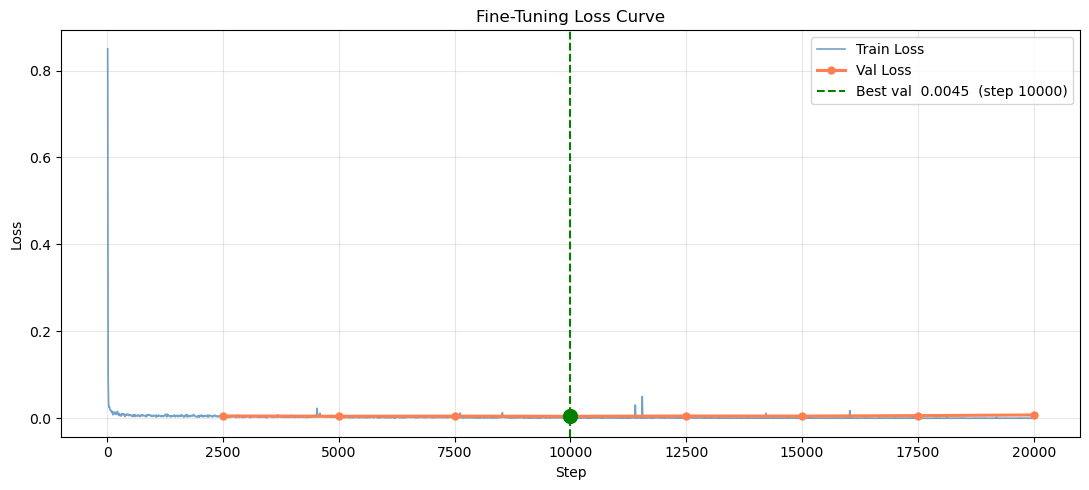

In [25]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(train_steps, train_losses,
        label="Train Loss", color="steelblue", alpha=0.75, linewidth=1.2)

ax.plot(eval_steps, eval_losses,
        label="Val Loss", color="coral", linewidth=2.2,
        marker="o", markersize=5)

# Mark the best checkpoint
ax.axvline(best_step, color="green", linestyle="--", linewidth=1.5,
           label=f"Best val  {best_loss:.4f}  (step {best_step})")
ax.scatter([best_step], [best_loss], color="green", zorder=5, s=100)

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Fine-Tuning Loss Curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

save_path = os.path.join(CHECKPOINT_DIR, "loss_curve.png")
plt.savefig(save_path, dpi=150)
plt.show()

Looking at them at the same time, it's a bit difficult to see how the validation loss is changing. I'll try plotting it alone to see if I can more clearly understand how the validation loss changes across epochs. 

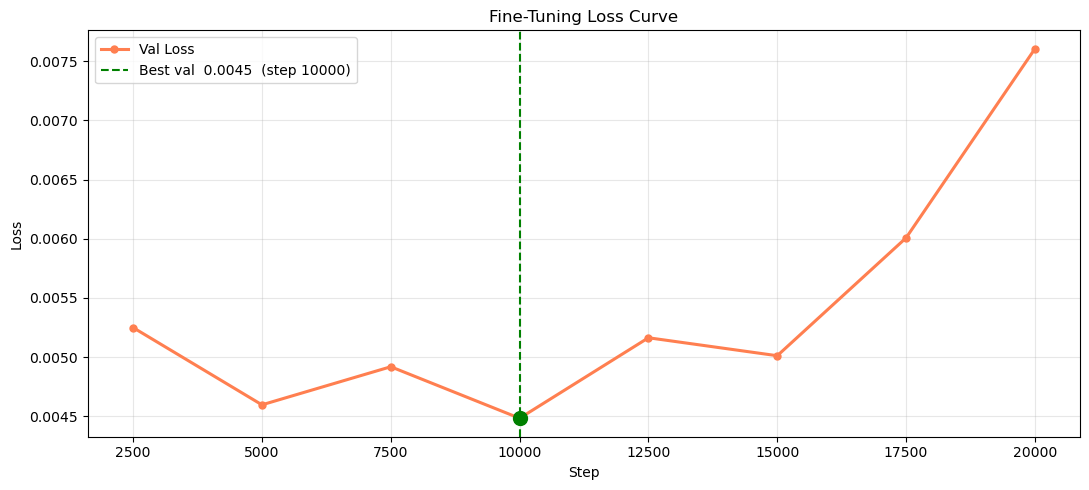

In [26]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(eval_steps, eval_losses,
        label="Val Loss", color="coral", linewidth=2.2,
        marker="o", markersize=5)

# Mark the best checkpoint
ax.axvline(best_step, color="green", linestyle="--", linewidth=1.5,
           label=f"Best val  {best_loss:.4f}  (step {best_step})")
ax.scatter([best_step], [best_loss], color="green", zorder=5, s=100)

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Fine-Tuning Loss Curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

save_path = os.path.join(CHECKPOINT_DIR, "loss_curve.png")
plt.savefig(save_path, dpi=150)
plt.show()

Here, we can see that the model first gets better before demonstrating clear overfitting behaviors as the loss steeply increases. Even from the first epoch to the 4th (the best), there isn't a significant difference in the validation accuracy. Throughout the rest of my project, I chose to use the model from checkpoint 4 as it demonstrates the lowest loss before the overfitting behavior becomes evident. I use checkpoint 4 for the 20k model and checkpoint 2 for the 3k model.